# De la date AirBox la concluzii statistice în R

## 1. Introducere în R și Google Colab

**R** este limbajul care execută analiza. Îl putem folosi pentru:
- citirea datelor;
- calcularea statisticilor;
- construirea graficelor;
- estimarea modelelor statistice.


**Google Colab** este o platformă online în care vom scrie explicațiile, vom rula codul R și vom vedea rezultatele în același notebook. Zonele principale sunt:
- Celule de cod — locul în care scriem și rulăm comenzile R;
- Celule text — locul pentru explicații, titluri, formule și observații;
- Output — rezultatele, tabelele, mesajele și graficele apar sub celula rulată;
- Files — fișierele încărcate sau create în sesiunea curentă.


Pentru a executa o celulă, apăsăm butonul ▶ din stânga acesteia sau folosim `Shift` + `Enter`. Celulele pot fi rulate separat, însă ordinea contează: un obiect trebuie creat înainte să poată fi utilizat.

## 2. Cum rulăm primul cod în R

In [ ]:
2 + 2

temperatura <- 23.5
temperatura
temperatura + 1

temperaturi <- c(22.5, 23.1, 23.4, 24.0)
mean(temperaturi)

[1] 4

[1] 23.5

[1] 24.5

[1] 23.25

### 2.1. Cum citim codul


- `<-` înseamnă „assign” sau „salvează această valoare sub acest nume”.
- `temperatura` este un **obiect**.
- `c()` combină mai multe valori într-un **vector**.
- `mean()` este o **funcție** care calculează media.
- Valorile introduse între paranteze sunt **argumentele** funcției.
- R diferențiază literele mari de cele mici: `temperatura` și `Temperatura` ar fi două obiecte diferite.


italicized text


### 2.2. Exercițiu: preziceți rezultatul


Înainte să rulezi codul, notează ce crezi că va afișa fiecare linie:

In [ ]:
co2 <- 750
co2
co2 + 100

masuratori <- c(600, 650, 700, 750, 800)
mean(masuratori)

[1] 750

[1] 850

[1] 700

## 3. Cum încărcăm și explorăm datele AirBox

Un set de date AirBox poate arăta astfel:


| timestamp | temperatură | umiditate | CO₂ |
|---|---:|---:|---:|
| 10:00 | 23,4 °C | 48% | 620 ppm |
| 10:05 | 23,5 °C | 49% | 645 ppm |
| 10:10 | 23,6 °C | 50% | 690 ppm |
| 10:15 | 23,8 °C | 51% | 735 ppm |

Termeni importanți:
- **rând** = o observație;
- **coloană** = o variabilă;
- **celulă** = valoarea unei variabile pentru o anumită observație;
- **data frame** = un tabel de observații și variabile.


Fiecare rând al setului AirBox reprezintă o măsurătoare făcută la un moment precis.

### 3.1. Importarea unui fișier CSV

In [ ]:
library(readr)

airbox <- read_csv("airbox_data.csv")

### 3.2. Inspectarea datelor

`head()` afișează primele rânduri.

In [ ]:
head(airbox)

`str()` arată structura setului și tipul fiecărei variabile.


In [ ]:
str(airbox)

`summary()` oferă un rezumat rapid al variabilelor.





In [ ]:
summary(airbox)

## 4. Tipurile variabilelor

Tipul variabilei determină ce operații și statistici au sens.


| Tipul variabilei | Cum apare | Exemplu AirBox |
|---|---|---|
| Numerică discretă | Se numără | numărul persoanelor |
| Numerică continuă | Se măsoară | temperatura, CO₂ |
| Categorică nominală | Categorii fără ordine | camera |
| Categorică ordinală | Categorii cu ordine | bună / moderată / slabă |

**Numerică discretă**
Ia valori separate, de obicei numere întregi. De exemplu, într-o cameră pot fi 2.0 sau 4.0 persoane, dar nu 2.4 persoane.


**Numerică continuă**
Poate lua, teoretic, orice valoare dintr-un interval. Temperatura rămâne conceptual continuă chiar dacă senzorul afișează un număr finit de zecimale.


**Categorică nominală**
Grupează observațiile în categorii care nu au o ordine naturală: laborator, clasă, exterior.


**Categorică ordinală**
Grupează observațiile în categorii ordonate: calitate bună, moderată sau slabă.

### 4.1. Exercițiu: identificați tipurile variabilelor


Clasifică fiecare variabilă:
1. PM2.5 în µg/m³;
2. numărul alertelor într-o zi;
3. camera în care se află senzorul;
4. nivelul de risc: scăzut, mediu, ridicat;
5. fereastra deschisă: da/nu.

## 5. Valorile lipsă

### 5.1. Ce este o valoare lipsă?


- senzorul nu a transmis date;
- dispozitivul s-a oprit;
- măsurarea a fost invalidă;
- fișierul a fost importat greșit.


**Valorile lipsă nu sunt 0**


Eliminarea valorilor lipsă este o decizie analitică, nu doar un truc de cod. Investigăm cauza înainte să eliminăm valorile.

În R, o valoare lipsă este reprezentată prin `NA` (*Not Available*).

In [ ]:
temperaturi <- c(22.5, 23.1, NA, 24.0)

Valorile lipsă pot afecta în mod negativ interpretările statistice. De exemplu calculul mediei.

In [ ]:
mean(temperaturi)

[1] NA

R nu poate calcula media completă fără să știe ce trebuie făcut cu valoarea lipsă. Argumentul `na.rm = TRUE` îi spune lui R să elimine valorile lipsă din calcul.

In [ ]:
mean(temperaturi, na.rm = TRUE)

[1] 23.2

Funcția `is.na()` identifică pozițiile în care apar valori lipsă

In [ ]:
is.na(temperaturi)

[1] FALSE FALSE  TRUE FALSE

## 6. Alegerea graficului

Graficul se alege în funcție de întrebare și de tipul variabilelor.

| Întrebarea | Variabile | Grafic potrivit |
|---|---|---|
| Cum evoluează CO₂ în timp? | timp + numerică | line graph |
| Cum sunt distribuite valorile PM2.5? | o numerică | histogram |
| Diferă CO₂ între camere? | categorică + numerică | boxplot |
| Temperatura și umiditatea sunt asociate? | două numerice | scatterplot |
| Câte observații sunt în fiecare categorie? | o categorică | bar chart |

## 7. Grafice în `ggplot2`


În `ggplot2`, construim graficul în straturi:

In [1]:
library(ggplot2)

Anatomia comenzii:
1. `airbox` — setul de **date**;
2. `aes(x = ..., y = ...)` — variabilele sau **esteticile**;
3. `geom_line()` — **geometria**, adică forma graficului;
4. `labs()` — titlul și **etichetele**.

### 7.1. Line graph — cum evoluează o variabilă în timp

In [ ]:
ggplot(airbox, aes(x = timestamp, y = co2)) +
  geom_line() +
  labs(
    title = "Evoluția CO₂ în timp",
    x = "Moment",
    y = "CO₂ (ppm)"
  )

### 7.2. Histogram — cum sunt distribuite valorile

In [ ]:
ggplot(airbox, aes(x = co2)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribuția valorilor CO₂",
    x = "CO₂ (ppm)",
    y = "Frecvență"
  )

### 7.3. Scatterplot — cum se modifică împreună două variabile

In [ ]:
ggplot(airbox, aes(x = temperatura, y = umiditate)) +
  geom_point() +
  labs(
    title = "Temperatură și umiditate",
    x = "Temperatură (°C)",
    y = "Umiditate (%)"
  )

### 7.4. Bar chart — cum comparăm categorii

In [ ]:
ggplot(airbox, aes(x = locație)) +
  geom_bar() +
  labs(
    title = "Numărul observațiilor în fiecare locație",
    x = "Locație",
    y = "Număr de observații"
  )

# Descrierea unei variabile

## 8. Cum comprimăm sute de măsurători

Un tabel cu sute sau mii de rânduri nu poate fi înțeles doar prin privire. Statistica ne ajută să comprimăm informația fără să pierdem povestea datelor.


Întrebări importante:
- Care este valoarea tipică?
- Cât de răspândite sunt observațiile?
- Ce formă are distribuția?
- Există vârfuri sau valori extreme?

## 9. Cum sunt distribuite valorile?

**Distribuția** descrie valorile pe care le ia o variabilă și frecvența cu care apar acestea.

In [ ]:
ggplot(airbox, aes(x = co2)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribuția valorilor CO₂",
    x = "CO₂ (ppm)",
    y = "Frecvență"
  )

De ce facem asta și nu ne uităm doar la medie?

Medie poate ascunde:
- valori stabile în jurul mediei;
- alternanțe mari între valori mici și mari;
- o distribuție asimetrică;
- câteva vârfuri extreme.


De aceea, privim împreună:
1. **forma** distribuției;
2. **centrul** distribuției;
3. **răspândirea** distribuției.

## 10. Cum descriem valoarea tipică?

### 10.1. Media — punctul de echilibru

Media folosește magnitudinea tuturor observațiilor și este sensibilă la valori extreme.

Media este punctul de echilibru al datelor:


$$
\bar{x}=\frac{x_1+x_2+\cdots+x_n}{n}
$$

In [ ]:
mean(airbox$co2, na.rm = TRUE)

### 10.2. Mediana — valoarea din mijloc

Mediana este valoarea din mijloc după ordonarea observațiilor.

$$ 100,\ 105,\ \boxed{110},\ 115,\ 1000 $$

In [ ]:
median(airbox$co2, na.rm = TRUE)

Jumătate dintre observații se află sub mediană, iar cealaltă jumătate se află peste ea.


Este mult mai puțin afectată de valorile extreme.

In [ ]:
voc_fara_varf <- c(100, 105, 110, 115, 120)
voc_cu_varf <- c(100, 105, 110, 115, 1000)

mean(voc_fara_varf)
median(voc_fara_varf)

mean(voc_cu_varf)
median(voc_cu_varf)

Valoarea extremă trage puternic media, dar mișcă greu mediana.


> Mediana nu ignoră observația extremă; este doar mai robustă, adică se schimbă mai puțin în prezența valorilor extreme.


Pentru date asimetrice sau cu vârfuri, este util să raportăm și mediana, nu doar media.


---


# De la observații la probabilitate


## 11. De la date observate la rezultate posibile


Până acum am descris măsurători deja observate. În continuare, modelăm procese incerte și valorile lor posibile.


Probabilitatea cuantifică incertitudinea:
- 0 = eveniment imposibil;
- 1 = eveniment sigur;
- 0,5 = probabilitate de 50%.


---


## 12. Ce este o variabilă aleatorie?


> O **variabilă aleatorie** atribuie un număr fiecărui rezultat posibil al unui proces incert.


„Aleatorie” înseamnă că valoarea este necunoscută înainte de observare, nu că fenomenul nu are cauze.


### 12.1. Variabile aleatorii discrete


- se numără;
- ia valori separate;
- exemplu: $X$ = numărul persoanelor care intră în laborator.


Putem calcula probabilitatea unei valori exacte:


$$
P(X=3)
$$


### 12.2. Variabile aleatorii continue


- se măsoară;
- poate lua orice valoare dintr-un interval;
- exemplu: $Y$ = temperatura la ora 14:00.


Lucrăm cu probabilitatea unui interval:


$$
P(20<Y<24)
$$


Pentru o variabilă continuă, probabilitatea unei singure valori exacte este, teoretic, zero.


### 12.3. Variabila aleatorie versus valoarea observată


- $X$ reprezintă variabila aleatorie și toate valorile posibile;
- $x=750$ ppm este o realizare concretă observată.


---


## 13. Cum descriem probabilitățile rezultatelor?


> Distribuția de probabilitate este un model al valorilor posibile ale unei variabile aleatorii și al probabilităților lor.


Exemplu:


| Numărul persoanelor, $X$ | 0 | 1 | 2 | 3 | 4 |
|---:|---:|---:|---:|---:|---:|
| $P(X=x)$ | 0,10 | 0,20 | 0,40 | 0,20 | 0,10 |

Suma tuturor probabilităților este:


$$
\sum_x P(X=x)=1
$$


### 13.1. Distribuția observată versus distribuția de probabilitate


- **Distribuția empirică** descrie ce am observat efectiv în date.
- **Distribuția de probabilitate** este un model matematic al procesului care produce datele.


### 13.2. Exercițiu: interpretați o distribuție


Folosind tabelul:


$$
P(X>2)=P(X=3)+P(X=4)=0{,}20+0{,}10=0{,}30
$$


Calculează:
1. $P(X=2)$;
2. $P(X\leq1)$;
3. $P(1<X<4)$.


---


## 14. Distribuția normală


Distribuția normală:
- are formă de clopot;
- este simetrică;
- are media, mediana și modul în același punct;
- este definită de media $\mu$ și deviația standard $\sigma$.


Notația este:


$$
X\sim N(\mu,\sigma^2)
$$


- $\mu$ stabilește centrul;
- $\sigma$ stabilește răspândirea;
- $\sigma^2$ este varianța.


> Nu toate variabilele din natură sunt distribuite normal. Nivelurile de poluare pot fi asimetrice și pot avea vârfuri extreme.


### 14.1. Vizualizarea distribuției normale în R

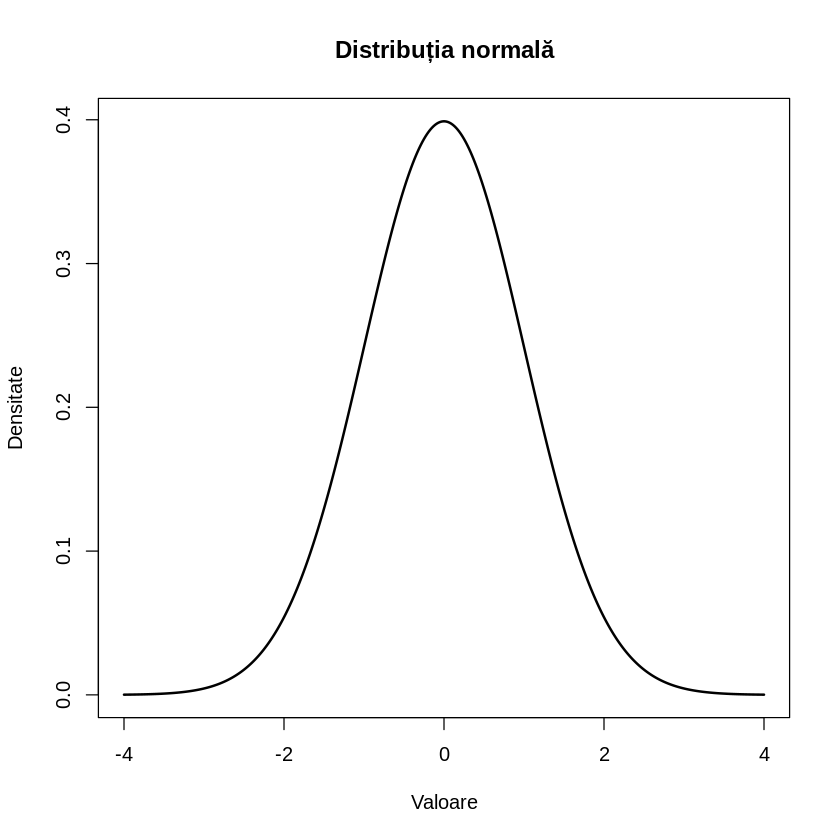

In [1]:
x <- seq(-4, 4, length.out = 400)
y <- dnorm(x, mean = 0, sd = 1)

plot(
  x, y,
  type = "l",
  lwd = 2,
  xlab = "Valoare",
  ylab = "Densitate",
  main = "Distribuția normală"
)

---


## 15. Cum modifică $\mu$ și $\sigma$ distribuția normală?


- Schimbarea lui $\mu$ deplasează distribuția la stânga sau la dreapta.
- Schimbarea lui $\sigma$ modifică răspândirea distribuției.
- O valoare mică a lui $\sigma$ produce o curbă îngustă.
- O valoare mare a lui $\sigma$ produce o curbă mai lată.

In [ ]:
x <- seq(15, 30, length.out = 500)

plot(
  x, dnorm(x, mean = 20, sd = 1),
  type = "l", lwd = 2, col = "blue",
  ylim = c(0, 0.42),
  xlab = "Temperatură (°C)",
  ylab = "Densitate",
  main = "Efectul mediei și al deviației standard"
)

lines(x, dnorm(x, mean = 23, sd = 1), lwd = 2, col = "deepskyblue")
lines(x, dnorm(x, mean = 23, sd = 2), lwd = 2, col = "tomato")

legend(
  "topright",
  legend = c(
    "μ = 20, σ = 1",
    "μ = 23, σ = 1",
    "μ = 23, σ = 2"
  ),
  col = c("blue", "deepskyblue", "tomato"),
  lwd = 2
)

> Deviația standard măsoară răspândirea valorilor, nu cât de „brusc” se schimbă seria în timp. Pentru caracterul brusc al schimbărilor trebuie să analizăm și ordinea temporală a observațiilor.


---


## 16. Cum interpretăm regula 68–95–99,7?


Pentru o distribuție aproximativ normală:
- aproximativ 68% dintre valori se află între $\mu-\sigma$ și $\mu+\sigma$;
- aproximativ 95% se află între $\mu-2\sigma$ și $\mu+2\sigma$;
- aproximativ 99,7% se află între $\mu-3\sigma$ și $\mu+3\sigma$.


Exemplu:


$$
\mu=22^\circ C,\qquad \sigma=1^\circ C
$$


| Interval | Proporție aproximativă |
|---|---:|
| 21–23 °C, adică $\mu\pm1\sigma$ | 68% |
| 20–24 °C, adică $\mu\pm2\sigma$ | 95% |
| 19–25 °C, adică $\mu\pm3\sigma$ | 99,7% |

> Regula nu trebuie aplicată automat datelor asimetrice sau unei distribuții care nu este aproximativ normală.


---


## 17. Cum calculăm probabilitatea pentru variabile continue?


### 17.1. Probability Density Function (PDF) — unde sunt concentrate valorile?


PDF arată unde sunt concentrate valorile unei variabile continue.


$$
P(a<X<b)=\text{aria de sub curbă între }a\text{ și }b
$$


Important:
- axa verticală reprezintă **densitatea**, nu probabilitatea directă;
- probabilitatea este o **arie**;
- aria totală de sub curbă este 1;
- înălțimea curbei într-un punct nu este probabilitatea exactă a acelui punct.


### 17.2. Cumulative Distribution Function (CDF) — câtă probabilitate s-a acumulat?


CDF arată câtă probabilitate s-a acumulat până la o anumită valoare:


$$
F(x)=P(X\leq x)
$$


Caracteristici:
- pornește de la 0;
- crește sau rămâne constantă;
- ajunge la 1.


### 17.3. PDF versus CDF


- **PDF:** unde sunt concentrate valorile?
- **CDF:** câtă probabilitate s-a acumulat până la $x$?


---


## 18. Cum calculăm densități și probabilități în R?


Presupunem că temperatura urmează o distribuție normală cu:


$$
\mu=22,\qquad \sigma=1
$$


### 18.1. Densitatea la o anumită valoare

In [3]:
dnorm(23, mean = 22, sd = 1)

[1] 0.2419707

`dnorm()` descrie înălțimea funcției de densitate. Rezultatul nu este probabilitatea ca temperatura să fie exact 23 °C.


### 18.2. Probabilitatea până la o anumită valoare

In [ ]:
pnorm(23, mean = 22, sd = 1)

`pnorm()` calculează probabilitatea acumulată până la valoarea introdusă.


### 18.3. Probabilitatea unui interval

In [ ]:
pnorm(23, mean = 22, sd = 1) -
  pnorm(21, mean = 22, sd = 1)

Regula generală:


$$
P(a\leq X\leq b)=F(b)-F(a)
$$


> Probabilitatea unui interval este CDF la capătul drept minus CDF la capătul stâng.


---


# Măsurarea răspândirii valorilor


## 19. De ce nu este suficientă valoarea medie?


Centrul distribuției nu este suficient. Două seturi pot avea aceeași medie, dar valori foarte diferit răspândite.


Întrebarea centrală este:
> Cât de departe se află, în mod obișnuit, observațiile față de medie?


## 20. Cum pot avea două seturi aceeași medie, dar valori diferite?


Setul A:


$$
21,\ 22,\ 23,\ 24,\ 25
$$


Setul B:


$$
13,\ 18,\ 23,\ 28,\ 33
$$


In [ ]:
set_A <- c(21, 22, 23, 24, 25)
set_B <- c(13, 18, 23, 28, 33)

In [ ]:
mean(set_A)
mean(set_B)

sd(set_A)
sd(set_B)

Ambele seturi au media 23, dar:
- setul A este concentrat în jurul lui 23;
- setul B este mult mai răspândit.

### 20.1. Întrebare de reflecție


Care set are deviația standard mai mare? Explică răspunsul înainte să rulezi ultimele două comenzi.


## 21. Cum măsurăm răspândirea prin varianță?


Varianța măsoară răspândirea prin abaterile pătratice față de medie.


### 21.1. Calculăm media


$$
\bar{x}=23
$$


### 21.2. Calculăm abaterile față de medie


$$
x_i-\bar{x}
$$


Pentru setul A:


| $x_i$ | $$x_i-\bar{x}$$|
|---:|---:|
| 21 | −2 |
| 22 | −1 |
| 23 | 0 |
| 24 | 1 |
| 25 | 2 |

Abaterile simple se anulează:


$$
-2-1+0+1+2=0
$$


### 21.3. Ridicăm abaterile la pătrat


$$
(x_i-\bar{x})^2
$$


Pătratele fac toate valorile nenegative și acordă o greutate mai mare abaterilor mari.


### 21.4. Calculăm media abaterilor pătratice


Pentru varianța unui eșantion:


$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

In [ ]:
var(set_A)
var(set_B)

În R, funcția `var()` folosește numitorul $n-1$, corespunzător varianței eșantionului.


Varianța:
- nu poate fi negativă;
- este mică atunci când valorile sunt apropiate de medie;
- este mare atunci când valorile sunt împrăștiate;
- are unitatea originală ridicată la pătrat.


---


## 22. Cum interpretăm răspândirea în unitatea originală?


Deviația standard este rădăcina pătrată a varianței:


$$
s=\sqrt{s^2}
$$

In [ ]:
var(airbox$temperatura, na.rm = TRUE)
sd(airbox$temperatura, na.rm = TRUE)

### 22.1. Varianța și deviația standard: unități de măsură


- dacă temperatura este măsurată în °C, varianța este exprimată în °C²;
- deviația standard revine la unitatea originală, adică °C.


Exemplu:
> O temperatură medie de 23 °C și o deviație standard de 0,5 °C indică valori relativ concentrate în jurul mediei.


Deviația standard poate fi interpretată ca o distanță tipică față de medie, dar nu trebuie transformată într-o regulă rigidă pentru distribuții foarte asimetrice.


---


# Analizarea relației dintre două variabile


## 23. Cum analizăm două variabile împreună?


Până acum am descris câte o singură variabilă. În continuare, investigăm dacă două variabile se mișcă împreună.


Exemple de întrebări AirBox:
- Crește CO₂ odată cu numărul persoanelor?
- Scade CO₂ atunci când fereastra este deschisă?
- Cresc VOC și PM2.5 în același timp?
- Se modifică împreună temperatura și umiditatea?


---


## 24. Cum măsoară covarianța mișcarea comună?


Covarianța verifică dacă abaterile a două variabile tind să aibă aceeași direcție.


$$
\operatorname{Cov}(X,Y)=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$


Pentru fiecare observație, verificăm poziția celor două variabile față de mediile lor:
- dacă ambele sunt peste medie, produsul abaterilor este pozitiv;
- dacă ambele sunt sub medie, produsul abaterilor este pozitiv;
- dacă una este peste medie și cealaltă sub medie, produsul este negativ.


Interpretare:
- $\operatorname{Cov}(X,Y)>0$ — variabilele tind să se miște în aceeași direcție;
- $\operatorname{Cov}(X,Y)<0$ — variabilele tind să se miște în direcții opuse;
- $\operatorname{Cov}(X,Y)\approx0$ — nu apare o relație liniară evidentă.

In [ ]:
cov(
  airbox$temperatura,
  airbox$umiditate,
  use = "complete.obs"
)

> Semnul covarianței este ușor de interpretat. Magnitudinea este mai dificilă, deoarece depinde de unitățile de măsură.


---


## 25. Cum standardizăm relația prin corelație?


Covarianța are două limite practice:
- magnitudinea sa depinde de unitățile de măsură;
- unitatea sa este produsul unităților celor două variabile.


$$
[\operatorname{Cov}(X,Y)]=[\text{unitatea lui }X]\times[\text{unitatea lui }Y]
$$


De exemplu, covarianța dintre temperatură și CO₂ ar putea avea unitatea °C × ppm.


Corelația Pearson standardizează covarianța:


$$
r=\frac{\operatorname{Cov}(X,Y)}{s_Xs_Y}
$$


$$
-1\leq r\leq1
$$


Corelația:
- arată direcția relației liniare;
- descrie intensitatea relației liniare;
- nu are unitate de măsură;
- poate fi comparată între perechi de variabile măsurate în unități diferite.

In [ ]:
cov(
  airbox$temperatura,
  airbox$umiditate,
  use = "complete.obs"
)

cor(
  airbox$temperatura,
  airbox$umiditate,
  use = "complete.obs"
)

Dacă transformăm temperatura din °C în °F:
- covarianța se schimbă;
- corelația rămâne aceeași.


---


## 26. Cum interpretăm direcția și intensitatea corelației?


Semnul lui $r$ indică direcția:
- $r>0$ — relație liniară pozitivă;
- $r<0$ — relație liniară negativă;
- $r\approx0$ — relație liniară slabă sau absentă.


Valoarea absolută $|r|$ indică intensitatea relației liniare:
- $|r|$ aproape de 1 — relație liniară puternică;
- $|r|$ aproape de 0 — relație liniară slabă.


Exemple vizuale:
- $r\approx+0{,}9$ — pozitivă și puternică;
- $r\approx+0{,}4$ — pozitivă și moderată;
- $r\approx0$ — fără o relație liniară evidentă;
- $r\approx-0{,}5$ — negativă și moderată;
- $r\approx-0{,}9$ — negativă și puternică.


### 26.1. Vizualizarea corelației printr-un scatterplot

In [ ]:
ggplot(airbox, aes(x = temperatura, y = umiditate)) +
  geom_point() +
  labs(
    title = "Relația dintre temperatură și umiditate",
    x = "Temperatură (°C)",
    y = "Umiditate (%)"
  )

Într-un scatterplot urmărim:
- direcția relației;
- intensitatea relației;
- forma relației;
- observațiile extreme;
- eventualele grupuri distincte.


> Pearson măsoară relații liniare. Un tipar curbat poate avea o corelație apropiată de zero, chiar dacă între variabile există o relație clară.


---


## 27. Ce nu ne spune corelația?


Corelația este un indiciu, nu o explicație cauzală.


### 27.1. Corelația nu demonstrează cauzalitatea


O asociere nu arată automat ce variabilă o produce pe cealaltă.


### 27.2. Corelația Pearson măsoară numai relația liniară


Pearson poate rata un tipar curbat.


### 27.3. Valorile extreme pot modifica rezultatul


Un singur punct neobișnuit poate modifica puternic coeficientul $r$.


### 27.4. O variabilă terță poate explica relația


Ventilația, numărul persoanelor sau activitatea din laborator pot influența simultan două măsurători.


Exemplu:
> Temperatura și VOC pot crește împreună, dar aceasta nu demonstrează că temperatura cauzează creșterea VOC. Ambele pot fi influențate de numărul persoanelor, de ventilație sau de activitățile din laborator.


Formula corectă este:
> „Temperatura este asociată cu VOC.”


Nu:
> „Temperatura cauzează VOC.”


---


## 28. Cum realizăm o analiză completă în R?


### 28.1. Inspectați datele

In [ ]:
head(airbox)
str(airbox)
summary(airbox)

### 28.2. Descrieți centrul și răspândirea

In [ ]:
mean(airbox$co2, na.rm = TRUE)
median(airbox$co2, na.rm = TRUE)
var(airbox$co2, na.rm = TRUE)
sd(airbox$co2, na.rm = TRUE)

### 28.3. Vizualizați distribuția

In [ ]:
library(ggplot2)

ggplot(airbox, aes(x = co2)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribuția valorilor CO₂",
    x = "CO₂ (ppm)",
    y = "Frecvență"
  )

### 28.4. Investigați relația dintre două variabile

In [ ]:
ggplot(airbox, aes(x = temperatura, y = umiditate)) +
  geom_point() +
  labs(
    title = "Temperatură și umiditate",
    x = "Temperatură (°C)",
    y = "Umiditate (%)"
  )

In [ ]:
cor(
  airbox$temperatura,
  airbox$umiditate,
  use = "complete.obs"
)

### 28.5. Formulați concluzia


Livrabilul trebuie să conțină:
1. tipurile variabilelor analizate;
2. centrul și răspândirea unei variabile;
3. o histogramă;
4. o corelație între două variabile;
5. o concluzie care nu afirmă cauzalitate.


### 28.6. Spațiu de lucru


**Variabila aleasă pentru distribuție:** ______________________________


**Tipul variabilei:** ________________________________________________


**Media:** ___________________________________________________________


**Mediana:** _________________________________________________________


**Deviația standard:** ______________________________________________


**Forma distribuției:** _____________________________________________


**Variabilele alese pentru relație:** _______________________________


**Corelația Pearson:** ______________________________________________


**Interpretarea:** __________________________________________________


---


## 29. Cum formulăm o concluzie statistică?


Completează:
> În perioada analizată, nivelul mediu al CO₂ a fost de **___ ppm**, cu o deviație standard de **___ ppm**. Distribuția a fost **___**. Între CO₂ și temperatură am observat o corelație Pearson de $r=\_\_\_$, ceea ce indică o relație liniară **___**. Această asociere nu demonstrează însă că una dintre variabile o cauzează pe cealaltă.


O concluzie bună include:
- **eșantionul** sau perioada analizată;
- **indicatorul** calculat;
- **valoarea** obținută;
- **interpretarea** rezultatului;
- **limita** concluziei.


### 29.1. Verificarea concluziei


- Am precizat variabilele analizate?
- Am precizat perioada sau eșantionul?
- Am raportat valorile statisticilor?
- Am descris direcția și intensitatea relației?
- Am evitat să confund asocierea cu efectul cauzal?


---


## 30. De la date la concluzie


# Parcursul complet al analizei


1. **Importăm și verificăm datele.**
2. **Alegem graficul după întrebare.**
3. **Descriem distribuția prin formă, centru și răspândire.**
4. **Investigăm relația dintre variabile.**
5. **Interpretăm unitățile și limitele.**
6. **Formulăm o concluzie proporțională cu dovezile.**


Ideile-cheie:
- variabilele pot fi numerice sau categorice;
- distribuția arată valorile și frecvența lor;
- media, mediana și modul descriu centrul;
- varianța și deviația standard descriu răspândirea;
- covarianța și corelația descriu mișcarea comună;
- corelația Pearson măsoară relații liniare;
- valorile extreme pot influența rezultatele;
- asocierea nu este automat cauzalitate.


### 30.1. Întrebarea finală


> Ce ai verifica înainte să crezi o concluzie bazată pe date?